# DELTA DIY MRI Workshop — Start MaRCoS and run a noise scan

This notebook gets `marcos_server` running on the Red Pitaya after a power-up, then runs Adelpha’s noise scan **in this same notebook** while the server stays up on the board.

It follows a simple path:

1. Find the Adelpha `console` tree and a writable data folder.
2. Set the Red Pitaya IP.
3. Check the SSH helper packages.
4. Probe the board (ICMP vs MaRCoS port 11111).
5. Load the FPGA bitstream and start `marcos_server` **on the board**.
6. Confirm the kernel is still free and the server is still answering.
7. Write the console noise-scan Pulseq file (zero-flip RF + ADC).
8. Run it through MaRCoS and plot the receiver noise.

**Session goal:** MaRCoS stays running on the Red Pitaya. This kernel only starts it, then acquires. Do not run `~/marcos_server` in the foreground in a cell.

Use the kernel that already has the Adelpha `console` tree on `sys.path` (this repo’s `console/.venv` is fine).


## Why the start cell does not block later cells

After every Red Pitaya power-up the MRI4ALL / MaRCoS sequence is:

1. Copy the FPGA bitstream onto the board.
2. SSH in as `root`.
3. Start `~/marcos_server`.

If you ran `ssh root@<IP> ~/marcos_server` **in a notebook cell**, that cell would sit there until you killed it, and nothing below it would run.

Adelpha’s helper (`console/services/ui/marcos_boot.py`) does the same work without holding this kernel:

- It logs in with Paramiko as `root`. You do not type a password. The documented MRI4ALL password is `root` unless you set `ADELPHA_MARCOS_SSH_PASSWORD`.
- On the board it starts `nohup ~/marcos_server … &`, so the process is detached from SSH.
- It closes the SSH session, waits until TCP port **11111** answers, then returns.

After Cell 5 prints `PASS`, MaRCoS is running on the Red Pitaya and this notebook can continue.

MaRCoS is **single-client**. Close any experiment or socket when a measurement finishes. Do not leave an idle SSH session or an open `Experiment` sitting across cells.


## Cell 1 — Locate the Adelpha console

Run this from `console/notebooks/` (or anywhere inside the Adelpha checkout). It puts `console` on `sys.path` and points logs at a writable `MRI4ALL_BASE` so imports do not try to write `/opt/mri4all`.


In [2]:
# Cell 1 — Locate the Adelpha console tree

import os
import sys
from pathlib import Path

print("Cell 1 — Console path")
print("---------------------")


def find_console_dir() -> Path:
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        if (folder / "services" / "ui" / "marcos_boot.py").is_file():
            return folder
        nested = folder / "console"
        if (nested / "services" / "ui" / "marcos_boot.py").is_file():
            return nested
    raise FileNotFoundError(
        "Could not find console/services/ui/marcos_boot.py. "
        "cd into the Adelpha checkout (or console/notebooks) and re-run."
    )


CONSOLE_DIR = find_console_dir()
ADELPHA_ROOT = CONSOLE_DIR.parent

if str(CONSOLE_DIR) not in sys.path:
    sys.path.insert(0, str(CONSOLE_DIR))

data_dir = ADELPHA_ROOT / ".mri4all"
os.environ["MRI4ALL_BASE"] = str(data_dir)
(data_dir / "logs").mkdir(parents=True, exist_ok=True)
(data_dir / "config").mkdir(parents=True, exist_ok=True)

print("  Console :", CONSOLE_DIR)
print("  Data    :", data_dir)
print("  Kernel  :", sys.executable)
print("  Python  :", sys.version.split()[0])
print("\nPASS: console is on sys.path.")


Cell 1 — Console path
---------------------
  Console : /Users/leokinyera/adelpha/console
  Data    : /Users/leokinyera/adelpha/.mri4all
  Kernel  : /Users/leokinyera/adelpha/console/.venv/bin/python
  Python  : 3.12.13

PASS: console is on sys.path.


## Cell 2 — Red Pitaya IP

MRI4ALL’s scanner Ethernet default is `10.42.0.251`. Edit `SCANNER_IP` if your board uses another address. A timeout usually means this computer is on Wi‑Fi instead of the scanner link (`10.42.0.x`).

Leave `FORCE_RESTART = False` unless you want Cell 5 to kill a running server and boot again.


In [4]:
# Cell 2 — Scanner IP and restart flag

print("Cell 2 — Scanner IP")
print("-------------------")

# Edit if your Red Pitaya is not at the MRI4ALL default.
SCANNER_IP = "169.254.44.172"
MARCOS_PORT = 11111
FPGA_DEVICE = "rp-122"  # rp-122 (122.88 MHz) or rp-125 (125 MHz)
FORCE_RESTART = False

try:
    import common.config as config

    config.load_config()
    cfg_file = config.get_config()
    if (cfg_file.scanner_ip or "").strip() != SCANNER_IP:
        cfg_file.scanner_ip = SCANNER_IP
        cfg_file.save_to_file()
        config.load_config()
        print("  Wrote scanner_ip to mri4all.json so run_pulseq uses this board.")
except Exception as exc:
    print("  Config not updated (", exc, ") — using SCANNER_IP as written.")

print("  SCANNER_IP    :", SCANNER_IP)
print("  MARCOS_PORT   :", MARCOS_PORT)
print("  FPGA_DEVICE   :", FPGA_DEVICE)
print("  FORCE_RESTART :", FORCE_RESTART)
print("\nPASS: board address is set.")


Cell 2 — Scanner IP
-------------------
  SCANNER_IP    : 169.254.44.172
  MARCOS_PORT   : 11111
  FPGA_DEVICE   : rp-122
  FORCE_RESTART : False

PASS: board address is set.


## Cell 3 — SSH helper packages

Starting MaRCoS from Python needs `paramiko` (SSH) and `msgpack` (the MaRCoS handshake). The workshop venv from notebook 01 may not have them yet. This cell installs any that are missing into the **current kernel**.


In [5]:
# Cell 3 — Check / install paramiko and msgpack

import importlib.util
import subprocess
import sys

print("Cell 3 — Packages")
print("-----------------")

needed = ["paramiko", "msgpack"]
missing = [name for name in needed if importlib.util.find_spec(name) is None]

if missing:
    print("Installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Already installed:", ", ".join(needed))

import msgpack  # noqa: E402
import paramiko  # noqa: E402

print("  paramiko:", paramiko.__version__)
print("  msgpack :", getattr(msgpack, "__version__", "ok"))
print("\nPASS: SSH helpers are available.")


Cell 3 — Packages
-----------------
Installing: paramiko, msgpack
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 8.4 MB/s  0:00:00m 8.4 MB/s eta 0:00:01
Using cached pycparser-3.0-py3-none-any.whl (48 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [paramiko]━━ 7/8 [paramiko]phy]
  paramiko: 5.0.0
  msgpack : 1.2.2

PASS: SSH helpers are available.


## Cell 4 — Probe the board (do not start the server yet)

This handshake opens TCP 11111, exchanges a MaRCoS packet, and **closes the socket**. That matters: `marcos_server` accepts one client at a time. An empty connect that is never closed can stall a later scan.

| Result | Meaning |
| --- | --- |
| `tcp` | MaRCoS is already up. Cell 5 will no-op unless `FORCE_RESTART` is True. |
| `icmp` | The board answers ping, but port 11111 is closed. Cell 5 should start the server. |
| `none` | This computer cannot see that IP. Check the Ethernet link before Cell 5. |


In [6]:
# Cell 4 — Probe Red Pitaya / MaRCoS

from services.ui.control import probe_scanner

print("Cell 4 — Probe")
print("--------------")

probe = probe_scanner(SCANNER_IP, port=MARCOS_PORT)
print("  reachable:", probe["reachable"])
print("  method   :", probe["method"])
print("  detail   :", probe["detail"])

if probe["method"] == "tcp":
    print("\nPASS: MaRCoS is already listening. Later cells can use the board.")
elif probe["method"] == "icmp":
    print("\nBoard is on the LAN. Run Cell 5 to load the bitstream and start marcos_server.")
else:
    print("\nFAIL: no response. Plug into the scanner Ethernet (often 10.42.0.x) and re-run.")


Cell 4 — Probe
--------------
  reachable: True
  method   : icmp
  detail   : 169.254.44.172 answers ping; MaRCoS port 11111 is closed ([Errno 61] Connection refused)

Board is on the LAN. Run Cell 5 to load the bitstream and start marcos_server.


## Cell 5 — Start MaRCoS, then let go

This cell may take a minute the first time (bitstream copy; compile `marcos_server` on the board if `~/marcos_server` is missing). That wait is only until the server answers on port 11111.

When it prints `PASS`, SSH is already closed. The process left running is on the Red Pitaya, not in this kernel. **Run the cells below without restarting anything.**

Do **not** replace this cell with a foreground `ssh root@… ~/marcos_server`.


In [7]:
# Cell 5 — Load bitstream and start marcos_server on the Red Pitaya
# The helper nohups the server on the board and closes SSH before returning.

from services.ui.marcos_boot import ensure_marcos_server

print("Cell 5 — Start MaRCoS")
print("---------------------")
print("  This kernel will block only until the board answers on port", MARCOS_PORT)
print("  After PASS, later cells in this notebook are free to run.\n")

result = ensure_marcos_server(
    SCANNER_IP,
    port=MARCOS_PORT,
    device=FPGA_DEVICE,
    force=FORCE_RESTART,
)

print("  ok       :", result["ok"])
print("  started  :", result["started"])
print("  bitstream:", result["bitstream"])
print("  compiled :", result["compiled"])
print("  detail   :", result["detail"])

if result["ok"]:
    print("\nPASS: marcos_server is running on the Red Pitaya.")
    print("This notebook kernel is free. Continue with the cells below.")
else:
    print("\nFAIL: MaRCoS did not come up.")
    print("Check SCANNER_IP, the Ethernet link, and that ssh root@%s works." % SCANNER_IP)


Cell 5 — Start MaRCoS
---------------------
  This kernel will block only until the board answers on port 11111
  After PASS, later cells in this notebook are free to run.



2026-09-11 11:31:51,627 | unknown | INF |  | MaRCoS SSH 169.254.44.172: date -u -s "2026-09-11 15:31:51" >/dev/null 2>&1 || date -Ins -s "2026-09-11 15:31:51" >/dev/null 2>&1 || true
2026-09-11 11:31:51,696 | unknown | INF |  | MaRCoS SSH 169.254.44.172: uname -n
2026-09-11 11:31:51,758 | unknown | INF |  | MaRCoS SCP marcos_fpga_rp-122.bit -> 169.254.44.172:/tmp/marcos_fpga.bit
2026-09-11 11:31:52,240 | unknown | INF |  | MaRCoS SSH 169.254.44.172: cat /tmp/marcos_fpga.bit > /dev/xdevcfg; rm -f /tmp/marcos_fpga.bit
2026-09-11 11:31:52,453 | unknown | INF |  | Loaded MaRCoS bitstream rp-122 onto 169.254.44.172 (rp-f0b667)
2026-09-11 11:31:52,454 | unknown | INF |  | MaRCoS SSH 169.254.44.172: test -x ~/marcos_server
2026-09-11 11:31:52,525 | unknown | INF |  | MaRCoS SSH 169.254.44.172: killall marcos_server >/dev/null 2>&1 || true
2026-09-11 11:31:52,601 | unknown | INF |  | MaRCoS SSH 169.254.44.172: nohup ~/marcos_server >/tmp/marcos_server.log 2>&1 </dev/null & echo $!
2026-09-11 1

  ok       : True
  started  : True
  bitstream: True
  compiled : False
  detail   : MaRCoS at 169.254.44.172:11111

PASS: marcos_server is running on the Red Pitaya.
This notebook kernel is free. Continue with the cells below.


## Cell 6 — Prove the kernel is free

Re-probe after Cell 5. If this cell runs, Jupyter was not stuck in an SSH session, and MaRCoS is still listening on the board for the noise-measurement cells that follow.


In [8]:
# Cell 6 — Confirm MaRCoS is up and this kernel can keep going

from services.ui.control import probe_scanner

print("Cell 6 — Kernel is free")
print("-----------------------")

probe = probe_scanner(SCANNER_IP, port=MARCOS_PORT)
print("  method:", probe["method"])
print("  detail:", probe["detail"])

if probe["method"] == "tcp":
    print("\nPASS: MaRCoS at %s:%s. Add noise-measurement cells below." % (SCANNER_IP, MARCOS_PORT))
else:
    print("\nFAIL: port %s is not answering. Re-run Cell 5 (set FORCE_RESTART = True if needed)." % MARCOS_PORT)


Cell 6 — Kernel is free
-----------------------
  method: tcp
  detail: MaRCoS at 169.254.44.172:11111

PASS: MaRCoS at 169.254.44.172:11111. Add noise-measurement cells below.


## Noise scan

A noise scan records the receiver **with RF flip angles at zero**. Gradients stay off. You are measuring coil / chain noise, not an echo.

Adelpha’s Imaging Console sequence `noisescan` does this with the same spin-echo *timing* as `make_rf_se`, but `FA1 = 0` and `FA2 = 0`. Those zero-flip pulses still exist as RF events so MaRCoS’s Pulseq translator has a TX waveform. An ADC-only `.seq` (no RF blocks) currently fails in that translator.

Defaults below match `console/sequences/noisescan.py`: TE 70 ms, TR 250 ms, 4096 samples over 6.4 ms.

MaRCoS is **single-client**. `run_pulseq` opens the board, runs, then closes the experiment. After that, later cells can run.



## Cell 7 — Noise-scan parameters

These are the same names the console sequence uses. Increase `NSA` if you want more averages (each average costs one TR).



In [27]:
# Cell 7 — Noise-scan parameters (same defaults as console/sequences/noisescan.py)

from pathlib import Path

print("Cell 7 — Parameters")
print("-------------------")

TE_MS = 70
TR_MS = 250
NSA = 1
ADC_SAMPLES = 4096
ADC_DURATION_US = 6400  # 4096 samples / 6.4 ms → 640 kHz bandwidth
FA1 = 0  # no excitation
FA2 = 0  # no refocusing pulse energy

SEQ_PATH = Path.cwd() / "noise_scan.seq"

print("  TE         :", TE_MS, "ms")
print("  TR         :", TR_MS, "ms")
print("  NSA        :", NSA)
print("  ADC samples:", ADC_SAMPLES)
print("  ADC window :", ADC_DURATION_US, "us")
print("  FA1 / FA2  :", FA1, "/", FA2, "(zero-flip; RF events still present)")
print("  seq file   :", SEQ_PATH)
print("\nPASS: noise-scan parameters are set.")



Cell 7 — Parameters
-------------------
  TE         : 70 ms
  TR         : 250 ms
  NSA        : 1
  ADC samples: 4096
  ADC window : 6400 us
  FA1 / FA2  : 0 / 0 (zero-flip; RF events still present)
  seq file   : /Users/leokinyera/adelpha/console/notebooks/noise_scan.seq

PASS: noise-scan parameters are set.


## Cell 8 — Write the Pulseq file

This calls the same helper the console noise scan uses (`sequences.common.make_rf_se.pypulseq_rfse`). It writes a spin-echo timeline with zero-flip RF, then an ADC.

PyPulseq may print `RuntimeWarning: invalid value encountered in divide`. That is expected when the flip angle is zero (RF amplitude is 0).



In [28]:
# Cell 8 — Write noise_scan.seq (zero-flip RF + ADC)

from sequences.common.make_rf_se import pypulseq_rfse

print("Cell 8 — Write sequence")
print("-----------------------")

ok = pypulseq_rfse(
    inputs={
        "TE": TE_MS,
        "TR": TR_MS,
        "NSA": NSA,
        "ADC_samples": ADC_SAMPLES,
        "ADC_duration": ADC_DURATION_US,
        "FA1": FA1,
        "FA2": FA2,
    },
    check_timing=True,
    output_file=str(SEQ_PATH),
)

if not ok or not SEQ_PATH.is_file():
    raise RuntimeError("Could not write %s" % SEQ_PATH)

print("  wrote:", SEQ_PATH, "(%s bytes)" % SEQ_PATH.stat().st_size)
print("\nPASS: Pulseq file is on disk.")



/Users/leokinyera/adelpha/console/pypulseq/Sequence/block.py:46: RuntimeWarning: invalid value encountered in divide
  mag = np.divide(mag, amplitude)
2026-09-11 12:41:45,253 | unknown | INF |  | Timing check passed successfully
2026-09-11 12:41:45,254 | unknown | INF |  | /Users/leokinyera/adelpha/console/notebooks/noise_scan.seq
2026-09-11 12:41:45,254 | unknown | INF |  | Writing sequence to file


Cell 8 — Write sequence
-----------------------
  wrote: /Users/leokinyera/adelpha/console/notebooks/noise_scan.seq (722 bytes)

PASS: Pulseq file is on disk.


## Cell 9 — Run on the Red Pitaya

`run_pulseq` translates the `.seq` file, talks to MaRCoS on `SCANNER_IP` from Cell 2, then **closes** the experiment so this kernel is free again.

This cell forces **hardware simulation off**. If simulation stays on, MaRCoS is never contacted and you get zero samples (Cell 10 then cannot plot a spectrum).

This cell may take a few seconds (sequence duration is about `NSA × TR`).


In [35]:
# Cell 9 — Acquire noise on MaRCoS, then disconnect

import numpy as np
import common.config as adelpha_config
import external.seq.adjustments_acq.config as cfg
from external.marcos_client import local_config as marcos_cfg
from external.marcos_client.local_config import apply_scanner_settings
from external.seq.adjustments_acq.scripts import run_pulseq

print("Cell 9 — Acquire")
print("----------------")

adelpha_config.load_config()
mri_cfg = adelpha_config.get_config()
changed = False
if (mri_cfg.scanner_ip or "").strip() != SCANNER_IP:
    mri_cfg.scanner_ip = SCANNER_IP
    changed = True
if mri_cfg.is_hardware_simulation():
    mri_cfg.hardware_simulation = "False"
    changed = True
    print("  Turned off hardware_simulation so this cell talks to the Red Pitaya.")
if changed:
    mri_cfg.save_to_file()
    adelpha_config.load_config()
apply_scanner_settings()
marcos_cfg.ip_address = SCANNER_IP
marcos_cfg.port = MARCOS_PORT

print("  MaRCoS :", marcos_cfg.ip_address, marcos_cfg.port)
print("  Larmor :", cfg.LARMOR_FREQ, "MHz")
print("  file   :", SEQ_PATH)

rxd, rx_t = run_pulseq(
    seq_file=str(SEQ_PATH),
    rf_center=cfg.LARMOR_FREQ,
    tx_t=1,
    grad_t=10,
    tx_warmup=100,
    shim_x=0,
    shim_y=0,
    shim_z=0,
    grad_cal=False,
    save_np=False,
    save_mat=False,
    save_msgs=True,
    gui_test=False,
    hardware_simulation=False,
    case_path=str(SEQ_PATH.parent),
)

rxd = np.asarray(rxd).ravel()
print("  samples:", rxd.size)
print("  dwell  :", rx_t, "us")
if rxd.size == 0:
    raise RuntimeError(
        "MaRCoS returned no ADC samples. Check Cell 6 (server up) and that "
        "hardware_simulation is off."
    )
print("\nPASS: acquisition finished. MaRCoS connection is closed; later cells can run.")


2026-09-11 12:47:49,094 | unknown | INF |  | Pulseq scan with Larmor 15.52
2026-09-11 12:47:49,095 | unknown | INF |  | Full-scale calibrations (DAC ±1): RF max 10000.0 Hz; Gx 8000000.0 Gy 9000000.0 Gz 10000000.0 Hz/m
2026-09-11 12:47:49,096 | unknown | INF |  | case path = /Users/leokinyera/adelpha/console/notebooks
2026-09-11 12:47:49,100 | unknown | INF |  | GPA grad_t=10.0 us
2026-09-11 12:47:49,101 | unknown | INF |  | Connecting to MaRCoS at 169.254.44.172:11111 (init_gpa=False)
2026-09-11 12:47:49,101 | unknown | INF |  | Connecting to MaRCoS at 169.254.44.172:11111
2026-09-11 12:47:49,108 | unknown | INF |  | Sending run_seq (2300 bytes) to MaRCoS


Cell 9 — Acquire
----------------
  MaRCoS : 169.254.44.172 11111
  Larmor : 15.52 MHz
  file   : /Users/leokinyera/adelpha/console/notebooks/noise_scan.seq


2026-09-11 12:47:49,324 | unknown | INF |  | Received MaRCoS messages: {'errors': ['gpa-fhdo gradient error; possibly missing samples'], 'infos': ['Client version 1.0.5 differs slightly from server version 1.0.6']}


  samples: 4096
  dwell  : 1.5625 us

PASS: acquisition finished. MaRCoS connection is closed; later cells can run.


## Cell 10 — Plot receiver noise

Time-domain magnitude and a simple spectrum. With zero flip angle you should see no echo — only noise (and any pickup in the lab).



Cell 10 — Plot
--------------
  samples: 4096
  dwell  : 1.5625 us
  rms |rx| : 0.0005316415541986408


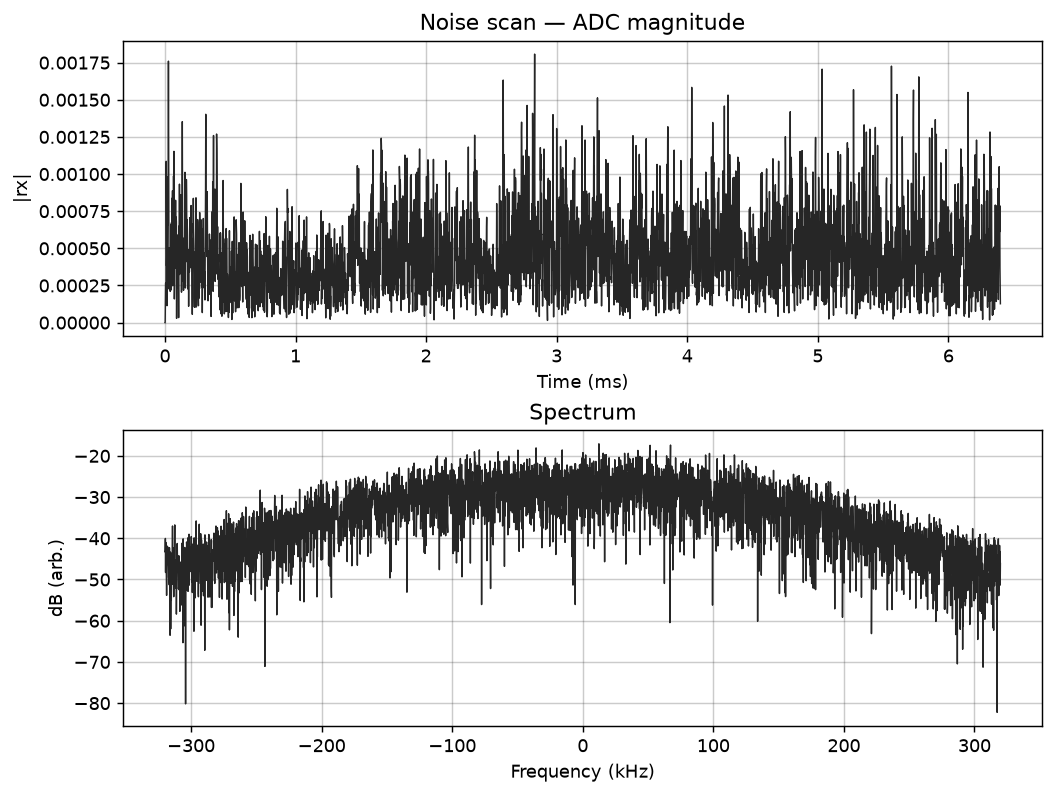


PASS: plots are above. Re-run Cell 9 to take another measurement; MaRCoS is still on the board.


In [37]:
# Cell 10 — Plot ADC noise

import matplotlib.pyplot as plt
import numpy as np

print("Cell 10 — Plot")
print("--------------")

rx = np.asarray(rxd).ravel()
dt_s = float(rx_t) * 1e-6
print("  samples:", rx.size)
print("  dwell  :", rx_t, "us")

if rx.size == 0 or dt_s <= 0:
    raise RuntimeError(
        "No ADC data to plot (samples=%s, dwell=%s us). Re-run Cell 9 with "
        "hardware_simulation off." % (rx.size, rx_t)
    )

time_ms = np.arange(rx.size) * dt_s * 1e3
frequency_hz = np.fft.fftshift(np.fft.fftfreq(rx.size, d=dt_s))
spectrum = np.fft.fftshift(np.fft.fft(rx))

print("  rms |rx| :", float(np.sqrt(np.mean(np.abs(rx) ** 2))))

fig, axes = plt.subplots(2, 1, figsize=(8, 6), constrained_layout=True)
axes[0].plot(time_ms, np.abs(rx), color="0.15", linewidth=0.8)
axes[0].set_title("Noise scan — ADC magnitude")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("|rx|")
axes[0].grid(True, color="#333", alpha=0.25)

axes[1].plot(frequency_hz / 1e3, 20 * np.log10(np.abs(spectrum) + 1e-12), color="0.15", linewidth=0.8)
axes[1].set_title("Spectrum")
axes[1].set_xlabel("Frequency (kHz)")
axes[1].set_ylabel("dB (arb.)")
axes[1].grid(True, color="#333", alpha=0.25)

# Console imports pin Matplotlib to Agg. Write a PNG and embed it in this cell.
from io import BytesIO
from IPython.display import Image, display

buf = BytesIO()
fig.savefig(buf, format="png", dpi=130, bbox_inches="tight", facecolor="white")
plt.close(fig)
display(Image(data=buf.getvalue()))

print("\nPASS: plots are above. Re-run Cell 9 to take another measurement; MaRCoS is still on the board.")


## Cell 11 — Live noise (repeating shots)

MaRCoS is **not** a continuous ADC stream. Each update is one full noise-scan shot (about one TR). This cell keeps a single TCP connection, runs the same `.seq` file in a loop, and redraws the plot after every shot.

- Set `LIVE_SHOTS` (default 20). Interrupt the kernel to stop early.
- The connection stays open for the whole loop, then closes so later cells can run.
- Do not Ping or run Cell 9 at the same time (single-client).



Cell 11 — Live noise
  shot 20 / 20   rms |rx| = 0.000485319


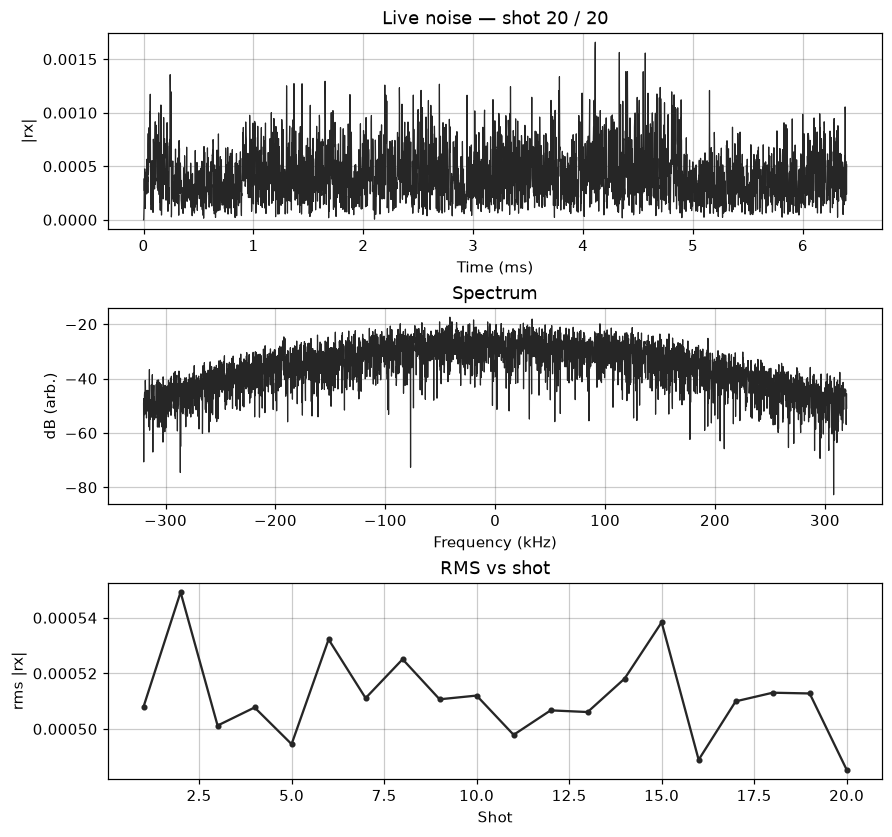


PASS: live loop finished. MaRCoS connection is closed.


In [40]:
# Cell 11 — Live noise: reuse one MaRCoS connection and redraw after each shot

from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, clear_output, display

import common.config as adelpha_config
import external.seq.adjustments_acq.config as cfg
from external.flocra_pulseq.interpreter_pp import seq2flocra
from external.marcos_client import experiment as ex
from external.marcos_client import local_config as marcos_cfg
from external.marcos_client.local_config import apply_scanner_settings
from external.seq.adjustments_acq.scripts import shim
from sequences.common.util import reading_json_parameter

LIVE_SHOTS = 20  # interrupt the kernel to stop sooner

print("Cell 11 — Live noise")
print("--------------------")

if not SEQ_PATH.is_file():
    raise FileNotFoundError("Run Cell 8 first so %s exists." % SEQ_PATH)

adelpha_config.load_config()
mri_cfg = adelpha_config.get_config()
if mri_cfg.is_hardware_simulation():
    mri_cfg.hardware_simulation = "False"
    mri_cfg.save_to_file()
    adelpha_config.load_config()
apply_scanner_settings()
marcos_cfg.ip_address = SCANNER_IP
marcos_cfg.port = MARCOS_PORT
cfg.update()

init_gpa = False
try:
    init_gpa = bool(reading_json_parameter().marcos_parameters.initialize_gpa)
except Exception:
    init_gpa = False

psi = seq2flocra(
    center_freq=cfg.LARMOR_FREQ * 1e6,
    rf_amp_max=cfg.RF_MAX,
    clk_freq=float(marcos_cfg.fpga_clk_freq_MHz),
    gx_max=cfg.GX_MAX,
    gy_max=cfg.GY_MAX,
    gz_max=cfg.GZ_MAX,
)
psi.load_seqfile(str(SEQ_PATH))
psi.block_events_to_amps_times()
instructions = shim(psi._flo_dict, (0, 0, 0))
rx_t = float(psi._rx_t)

print("  MaRCoS :", marcos_cfg.ip_address, marcos_cfg.port)
print("  shots  :", LIVE_SHOTS)
print("  dwell  :", rx_t, "us")
print("  Interrupt the kernel to stop early.\n")


def _live_png(rx, dwell_us, rms_hist, shot):
    dt_s = dwell_us * 1e-6
    time_ms = np.arange(rx.size) * dt_s * 1e3
    frequency_hz = np.fft.fftshift(np.fft.fftfreq(rx.size, d=dt_s))
    spectrum = np.fft.fftshift(np.fft.fft(rx))
    fig, axes = plt.subplots(3, 1, figsize=(8, 7.5), constrained_layout=True)
    axes[0].plot(time_ms, np.abs(rx), color="0.15", linewidth=0.8)
    axes[0].set_title("Live noise — shot %d / %d" % (shot, LIVE_SHOTS))
    axes[0].set_xlabel("Time (ms)")
    axes[0].set_ylabel("|rx|")
    axes[1].plot(frequency_hz / 1e3, 20 * np.log10(np.abs(spectrum) + 1e-12), color="0.15", linewidth=0.8)
    axes[1].set_title("Spectrum")
    axes[1].set_xlabel("Frequency (kHz)")
    axes[1].set_ylabel("dB (arb.)")
    axes[2].plot(np.arange(1, len(rms_hist) + 1), rms_hist, color="0.15", marker="o", markersize=3)
    axes[2].set_title("RMS vs shot")
    axes[2].set_xlabel("Shot")
    axes[2].set_ylabel("rms |rx|")
    for ax in axes:
        ax.grid(True, color="#333", alpha=0.25)
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return buf.getvalue()


expt = ex.Experiment(
    lo_freq=cfg.LARMOR_FREQ,
    rx_t=rx_t,
    init_gpa=init_gpa,
    gpa_fhdo_offset_time=psi._grad_t / 3,
    grad_max_update_rate=0.0625,
    halt_and_reset=True,
)
expt.add_flodict(instructions, append=False)

rms_hist = []
try:
    for shot in range(1, LIVE_SHOTS + 1):
        rx_map, _msgs = expt.run()
        rx = np.asarray(rx_map.get("rx0", [])).ravel()
        if rx.size == 0:
            raise RuntimeError("Shot %d returned no ADC samples." % shot)
        rms_hist.append(float(np.sqrt(np.mean(np.abs(rx) ** 2))))
        clear_output(wait=True)
        print("Cell 11 — Live noise")
        print("  shot %d / %d   rms |rx| = %.6g" % (shot, LIVE_SHOTS, rms_hist[-1]))
        display(Image(data=_live_png(rx, rx_t, rms_hist, shot)))
finally:
    try:
        expt.__del__()
    except Exception:
        pass

print("\nPASS: live loop finished. MaRCoS connection is closed.")



## Done

- MaRCoS is still running on the Red Pitaya (`nohup ~/marcos_server`). You do not need Cell 5 again unless the board was power-cycled or you set `FORCE_RESTART = True`.
- Re-run Cell 6 if a later acquisition fails with a connection error.
- Cell 11 holds the MaRCoS socket until the live loop ends (or you interrupt). Then later cells can run again.
- This is the same measurement as **Noise Scan** in the Imaging Console (`console/sequences/noisescan.py`).

